In [1]:
%pip install -r requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Solution — Module M1: เทรน 3 แบบบนข้อมูลเดียวกัน

เฉลยครบทุกข้อของ `exercise.ipynb` โมดูลเดียวกัน (เปิดให้ดูหลังจบแล็บ)

**Dataset:** Fashion-MNIST — Xiao et al. (2017), arXiv:1708.07747, <https://github.com/zalandoresearch/fashion-mnist>, **License: MIT**

## 0. เตรียมข้อมูล

In [2]:
from pathlib import Path


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


DATA = repo_root() / "data"

In [3]:
import numpy as np  # noqa: E402
from torchvision.datasets import FashionMNIST  # noqa: E402

# download=True: ดาวน์โหลดครั้งแรกลง data/ (gitignored) — บนเครื่อง
# offline ที่ pre-bundle ไว้แล้ว จะโหลดจากดิสก์ทันทีไม่ใช้เน็ต
train_full = FashionMNIST(root=DATA, train=True, download=True)
test_full = FashionMNIST(root=DATA, train=False, download=True)
print(train_full.data.shape, test_full.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
# fixed subsample 10k/2k — เพื่อให้ทั้ง lab จบในเวลาไม่กี่นาทีบน CPU
# (ผลเมื่อใช้เต็ม 60k/10k อ้างอิงไว้ในสรุปท้ายโมดูล)
N_TRAIN, N_TEST = 10_000, 2_000
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(train_full.data), N_TRAIN, replace=False)
idx_te = rng.choice(len(test_full.data), N_TEST, replace=False)
X_train = train_full.data.numpy()[idx_tr]
y_train = train_full.targets.numpy()[idx_tr]
X_test = test_full.data.numpy()[idx_te]
y_test = test_full.targets.numpy()[idx_te]
print(X_train.shape, X_test.shape)

(10000, 28, 28) (2000, 28, 28)


In [5]:
CLASS_EN = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

## ข้อ 1 — HOG cell=7 vs cell=4

cell ใหญ่ขึ้น → รายละเอียดหาย (144 มิติ vs 441) → accuracy แย่ลงเล็กน้อย

In [6]:
import numpy as np  # noqa: E402


def hog_features(imgs, cell=4, bins=9):
    """HOG แบบย่อ: gradient -> histogram มุมต่อ cell -> L2 normalize.

    imgs: (N, 28, 28) uint8 -> return (N, (28/cell)^2 * bins) float32
    """
    imgs = imgs.astype(np.float32)
    gx = np.empty_like(imgs)
    gy = np.empty_like(imgs)
    gx[:, :, 1:-1] = imgs[:, :, 2:] - imgs[:, :, :-2]
    gy[:, 1:-1, :] = imgs[:, 2:, :] - imgs[:, :-2, :]
    mag = np.hypot(gx, gy)
    ang = np.arctan2(gy, gx) % np.pi
    ny, nx = imgs.shape[1] // cell, imgs.shape[2] // cell
    b = np.floor(ang / (np.pi / bins)).astype(int) % bins
    feats = np.zeros((len(imgs), ny * nx * bins), dtype=np.float32)
    for i in range(len(imgs)):
        f = feats[i].reshape(ny, nx, bins)
        for cy in range(ny):
            for cx in range(nx):
                sl_m = mag[i, cy * cell:(cy + 1) * cell,
                           cx * cell:(cx + 1) * cell]
                sl_b = b[i, cy * cell:(cy + 1) * cell,
                         cx * cell:(cx + 1) * cell]
                f[cy, cx] = np.bincount(
                    sl_b.ravel(), weights=sl_m.ravel(), minlength=bins
                )
        feats[i] = (f / (np.linalg.norm(f) + 1e-6)).ravel()
    return feats

In [7]:
# คำนวณ HOG feature ด้วย cell=4 (ค่า default ของ book.ipynb)
Ftr_hog = hog_features(X_train)
Fte_hog = hog_features(X_test)
print(Ftr_hog.shape, Fte_hog.shape)

(10000, 441) (2000, 441)


In [8]:
from sklearn.metrics import accuracy_score  # noqa: E402
from sklearn.svm import LinearSVC  # noqa: E402

svm4 = LinearSVC(C=1.0, max_iter=5000, dual="auto").fit(Ftr_hog, y_train)
print(f"cell=4 accuracy = "
      f"{accuracy_score(y_test, svm4.predict(Fte_hog)):.4f}")

cell=4 accuracy = 0.8660


In [9]:
Ftr_7 = hog_features(X_train, cell=7)
Fte_7 = hog_features(X_test, cell=7)
svm7 = LinearSVC(C=1.0, max_iter=5000, dual="auto").fit(Ftr_7, y_train)
print(f"cell=7 accuracy = "
      f"{accuracy_score(y_test, svm7.predict(Fte_7)):.4f}")

cell=7 accuracy = 0.8235


**คำตอบข้อ 1:** `cell=7` แย่ลง (0.8235 vs 0.8660 — จากผล print) — cell ใหญ่เฉลี่ย gradient ทั้ง cell ทำให้เหลือเพียง "ขอบหยาบ" รายละเอียดเล็ก (จักรเย็บผ้า, สายรัดรองเท้า) หายไป นี่คือ **trade-off ของการออกแบบ feature ด้วยมือ**: ทุกตัวเลือก (ขนาด cell, bins) ต้องลองเอง — ต่างจาก CNN ที่เรียนรู้เองจากข้อมูล

## ข้อ 2 — CNN 20 epochs

In [10]:
import torch  # noqa: E402
import torch.nn as nn  # noqa: E402
from torch.utils.data import DataLoader, TensorDataset  # noqa: E402

Xtr_t = torch.from_numpy(X_train).float().unsqueeze(1) / 255.0
Xte_t = torch.from_numpy(X_test).float().unsqueeze(1) / 255.0
ytr_t = torch.from_numpy(y_train)
mean, std = Xtr_t.mean(), Xtr_t.std()
Xtr_n = (Xtr_t - mean) / std
Xte_n = (Xte_t - mean) / std
print(f"normalize: mean={mean:.4f} std={std:.4f}")


class SmallCNN(nn.Module):
    """CNN จิ๋ว 2 ชั้น conv — ตั้งใจให้เล็กพอรันบน CPU ได้เร็ว."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_cnn(X, y, epochs=10, bs=128, seed=0, log_every=0):
    """เทรน CNN ด้วย Adam คืนโมเดลที่เทรนแล้ว."""
    torch.manual_seed(seed)
    model = SmallCNN()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(
        TensorDataset(X, y), batch_size=bs, shuffle=True, generator=g
    )
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if log_every and (ep + 1) % log_every == 0:
            print(f"  epoch {ep + 1}/{epochs}: loss={loss.item():.4f}")
    return model


def cnn_accuracy(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xte_n).argmax(1).numpy()
    return accuracy_score(y_test, pred)

normalize: mean=0.2867 std=0.3535


In [11]:
from sklearn.metrics import accuracy_score  # noqa: E402

cnn20 = train_cnn(Xtr_n, ytr_t, epochs=20)
print(f"CNN 20 epochs accuracy = {cnn_accuracy(cnn20):.4f}")

CNN 20 epochs accuracy = 0.8600


**คำตอบข้อ 2:** ดูผลจริงก่อน: 10 epochs ~0.87 แต่ 20 epochs ได้ **~0.86 — ต่ำกว่าเดิมเล็กน้อย!** บทเรียน: **เทรนนานขึ้นไม่ได้แปลว่าดีขึ้นเสมอ** เมื่อ test accuracy อิ่มตัว (~0.86–0.88 สำหรับสถาปัตยกรรมจิ๋วนี้) การเทรนต่อจะเริ่ม overfit train set (train accuracy → 99% แต่ test ไม่ขยับ/แกว่งลงตาม noise การเทรน) การเลือกจุดหยุดเทรน (early stopping) คือทักษะจริงของการเทรน — และการเทียบโมเดลต้องเทียบบน test set เสมอ

## ข้อ 3 — คู่สับสนมากที่สุด

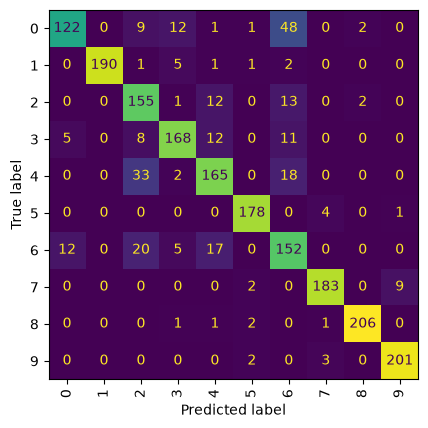

สับสนมากสุด: จริง=T-shirt ถูกทำนายเป็น=Shirt (48 ครั้ง)


In [12]:
import matplotlib.pyplot as plt  # noqa: E402
from sklearn.metrics import ConfusionMatrixDisplay  # noqa: E402

cnn20.eval()
with torch.no_grad():
    pred20 = cnn20(Xte_n).argmax(1).numpy()
ConfusionMatrixDisplay.from_predictions(
    y_test, pred20, colorbar=False, xticks_rotation=90
)
plt.show()

cm = np.zeros((10, 10), dtype=int)
for true, pr in zip(y_test, pred20):
    cm[true, pr] += 1
np.fill_diagonal(cm, 0)
worst_i, worst_j = np.unravel_index(np.argmax(cm), cm.shape)
print(
    f"สับสนมากสุด: จริง={CLASS_EN[worst_i]} "
    f"ถูกทำนายเป็น={CLASS_EN[worst_j]} ({cm[worst_i, worst_j]} ครั้ง)"
)

**คำตอบข้อ 3:** จากผล print: **จริง T-shirt ถูกทำนายเป็น Shirt (48 ครั้ง)** — ยังอยู่ใน "ตระกูลเสื้อ" สมเหตุสมผล: Shirt กับ T-shirt หน้าตาเหมือนกันในภาพขาวดำ 28×28 (ทรงเสื้อ + แขน) แม้คนก็แยกยาก และใน book.ipynb (โมเดล 10 epochs) ทิศกลับ Shirt→T-shirt ก็เด่นเช่นกัน — คู่นี้สับสน **ทั้งสองทิศทาง** ใน M7 เราจะกลับมาดูว่า "โมเดลมองจุดไหน" ที่ทำให้สับสนด้วย Grad-CAM

## ข้อ 4 — เติมจุด 50% ของ learning curve

In [13]:
accs = {500: None, 2500: None, 5000: None}
for n in accs:
    svm_n = LinearSVC(C=1.0, max_iter=5000, dual="auto").fit(
        Ftr_hog[:n], y_train[:n]
    )
    accs[n] = accuracy_score(y_test, svm_n.predict(Fte_hog))
    print(f"n={n}: accuracy={accs[n]:.4f}")

n=500: accuracy=0.8170


n=2500: accuracy=0.8450


n=5000: accuracy=0.8560


**คำตอบข้อ 4:** ค่าที่ 50% อยู่ระหว่างค่าของ 25% กับ 100% (เทียบกับตัวเลขจาก book.ipynb: ~0.845 ที่ 25% และ ~0.866 ที่ 100%) — เสริม curve ให้ต่อเนื่องตามแนวโน้ม "ข้อมูลมากขึ้น → accuracy ดีขึ้นแต่กำไรลดลง"

## ข้อ 5 — ตัดสินใจเลือกวิธีเมื่อมีข้อมูล 200 ภาพ

**คำตอบ (ตัวอย่างที่ยุติธรรม — อ้าง learning curve ของเรา):**

เลือก **transfer learning (freeze + เทรน head)** เป็นตัวเลือกแรก เหตุผล:

1. **Learning curve ชี้ว่า 200 ภาพคือโซนอันตรายของ "เทรนจากศูนย์"** — ที่ 500 ภาพ CNN จากศูนย์ทำได้แค่ ~0.73 ต่ำกว่า HOG+SVM (~0.82) ยิ่ง 200 ภาพยิ่งแย่กว่านั้น ส่วน head ของ transfer เทรนบน feature ที่เรียนรู้จาก 1.2 ล้านภาพ ImageNet จึงไม่ต้องพึ่งข้อมูลของเรามาก
2. **โจทย์เมโทรโลยีคือภาพจริงสี** (ไม่ใช่ 28×28 ขาวดำ) — ImageNet features สร้างมาเพื่อภาพจริง จึงยิ่งเหมาะ ขณะที่ HOG ออกแบบบนสมมติฐาน "ขอบเด่นชัด" อาจโดนพื้นหลัง/แสงกลืน

**แต่** ถ้าหัวหน้าต้องการ "โมเดลที่อธิบายได้ว่าทำไม" ภายในสัปดาห์ HOG+SVM ก็เป็นทางเลือกจริงจัง — baseline ง่าย เทรนวินาทีเดียว และที่ข้อมูลระดับหลักร้อยมักไม่แพ้ห่าง (ทำสองอย่างเทียบกันเสมอ!)